# Assignment 9: RNN for Stock Price Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

import yfinance as yf

In [2]:
df = yf.download('AAPL', start='2022-01-01', end='2024-01-01')

df = df[['Close']]
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2022-01-03,178.103683
2022-01-04,175.843262
2022-01-05,171.165817
2022-01-06,168.308487
2022-01-07,168.474869


In [3]:
train_size = int(len(df)*0.8)

train_data = df[:train_size]
test_data = df[train_size:]

In [4]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [5]:
def create_dataset(data, window=30):
    X, y = [], []
    
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_scaled)
X_test, y_test = create_dataset(test_scaled)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [6]:
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(SimpleRNN(50))

model.add(Dense(1))

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [8]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1255
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0207
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0093
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0057
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0040
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0035
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0032
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0030
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0034
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0032


In [9]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


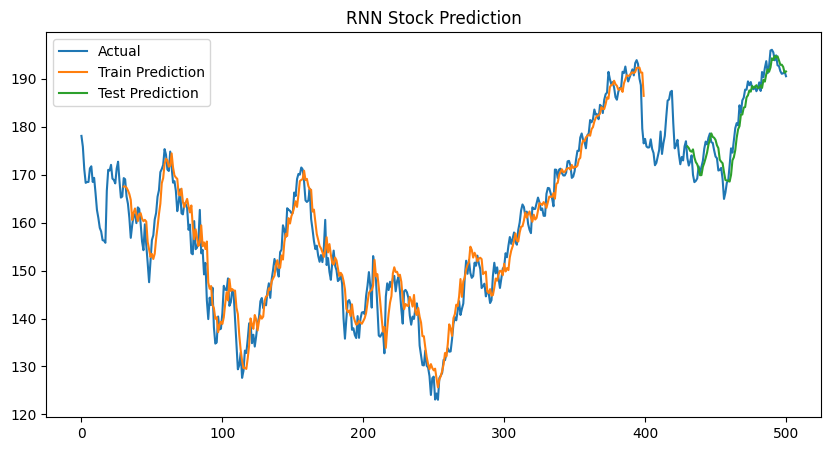

In [10]:
plt.figure(figsize=(10,5))

plt.plot(df.values, label='Actual')

plt.plot(range(30, len(train_pred)+30), train_pred, label='Train Prediction')

plt.plot(range(len(train_pred)+60, len(train_pred)+60+len(test_pred)), test_pred, label='Test Prediction')

plt.legend()
plt.title("RNN Stock Prediction")

plt.show()

In [11]:
last_30 = test_scaled[-30:]

future = []

current_input = last_30.reshape(1,30,1)

for i in range(7):
    
    pred = model.predict(current_input)[0][0]
    future.append(pred)
    
    current_input = np.append(current_input[:,1:,:], [[[pred]]], axis=1)

future = scaler.inverse_transform(np.array(future).reshape(-1,1))

print("Next 7 Days Prediction:")
print(future)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Next 7 Days Prediction:
[[190.76204]
 [191.32375]
 [191.28325]
 [191.1833 ]
 [191.4716 ]
 [191.46356]
 [191.76884]]
